In [1]:
from ofdm.plots import plot_dataset_mapping
import torch
from nnscf import denormalize
import os
import time

In [2]:
og_pt_dir = "./testraw/"
pt_dir = "./testnorm/"
os.makedirs(og_pt_dir, exist_ok=True)
os.makedirs(pt_dir, exist_ok=True)

# mod = "16qam" # Make sure this matches the data you want to fix!
mod = "qpsk" # Make sure this matches the data you want to fix!

# clipping technique
# tech = "icf"
tech = "scf"

datasize = 100
# datasize = 120
# train_size = 80
train_size = 70 # should be the same as the one used in nnicf.ipynb, obviously
val_size = 10
test_size = 100 - train_size - val_size

params = f"{tech.upper()} {mod.upper()} (N=256, L=4, CR=6dB)"
title = f"Data Mapping\n{params}"

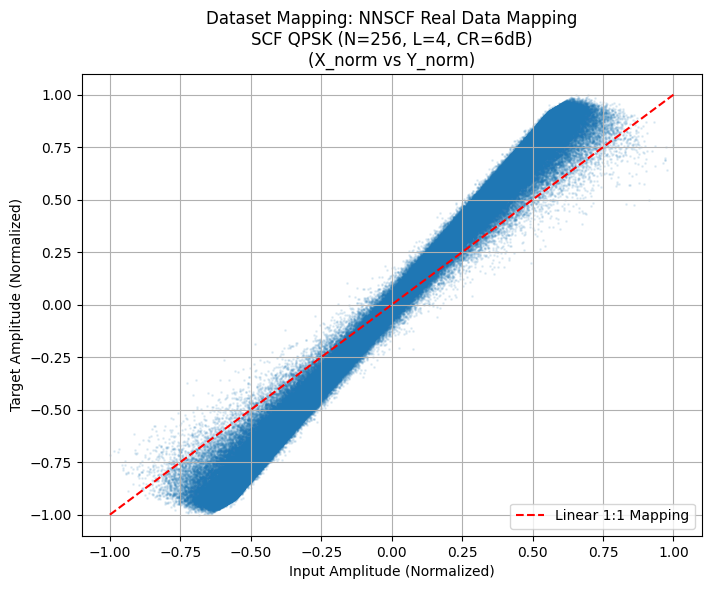

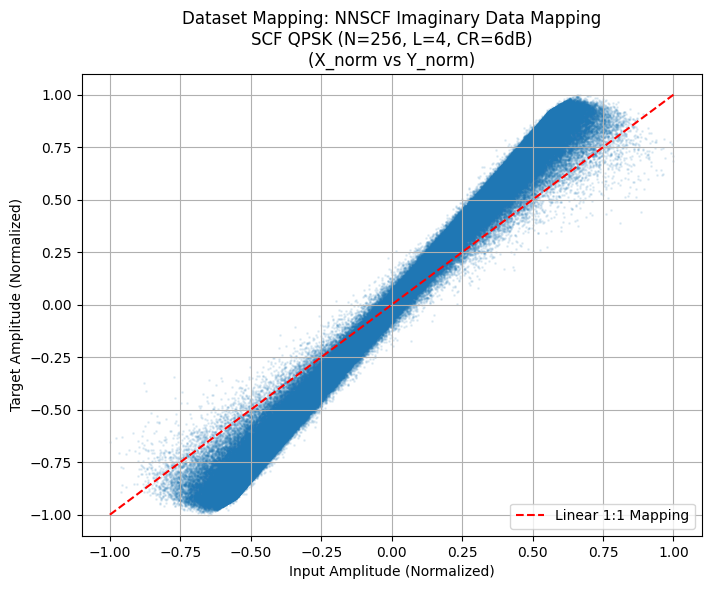

In [3]:
plot_dataset_mapping(os.path.join(og_pt_dir, f"{mod}_scf_part_{0:03d}_real.pt"), "NNSCF Real " + title)
plot_dataset_mapping(os.path.join(og_pt_dir, f"{mod}_scf_part_{0:03d}_imag.pt"), "NNSCF Imaginary " + title)

In [4]:
print("--- STEP 1: Finding Global Limits from Training Data (Files 0 to train_size - 1) ---")
# Initialize global trackers
g_X_r_min, g_X_r_max = float('inf'), float('-inf')
g_Y_r_min, g_Y_r_max = float('inf'), float('-inf')
g_X_i_min, g_X_i_max = float('inf'), float('-inf')
g_Y_i_min, g_Y_i_max = float('inf'), float('-inf')

--- STEP 1: Finding Global Limits from Training Data (Files 0 to train_size - 1) ---


In [5]:
# Only scan the first train_size files to prevent Data Leakage!
for i in range(train_size):
    # Load dictionaries
    data_real = torch.load(os.path.join(og_pt_dir, f"{mod}_{tech}_part_{i:03d}_real.pt"), weights_only=True)
    data_imag = torch.load(os.path.join(og_pt_dir, f"{mod}_{tech}_part_{i:03d}_imag.pt"), weights_only=True)

    # Extract local limits and update globals
    g_X_r_min = min(g_X_r_min, data_real['X_min'])
    g_X_r_max = max(g_X_r_max, data_real['X_max'])
    g_Y_r_min = min(g_Y_r_min, data_real['Y_min'])
    g_Y_r_max = max(g_Y_r_max, data_real['Y_max'])

    g_X_i_min = min(g_X_i_min, data_imag['X_min'])
    g_X_i_max = max(g_X_i_max, data_imag['X_max'])
    g_Y_i_min = min(g_Y_i_min, data_imag['Y_min'])
    g_Y_i_max = max(g_Y_i_max, data_imag['Y_max'])
    print(f"Found Local Real X Limits: Min = {data_real['X_min']:.4f}, Max = {data_real['X_max']:.4f}")

print(f"Found Global Real X Limits: Min = {g_X_r_min:.4f}, Max = {g_X_r_max:.4f}")

Found Local Real X Limits: Min = -0.2238, Max = 0.2239
Found Local Real X Limits: Min = -0.2310, Max = 0.2279
Found Local Real X Limits: Min = -0.2274, Max = 0.2326
Found Local Real X Limits: Min = -0.2187, Max = 0.2272
Found Local Real X Limits: Min = -0.2295, Max = 0.2463
Found Local Real X Limits: Min = -0.2327, Max = 0.2469
Found Local Real X Limits: Min = -0.2254, Max = 0.2248
Found Local Real X Limits: Min = -0.2439, Max = 0.2201
Found Local Real X Limits: Min = -0.2684, Max = 0.2273
Found Local Real X Limits: Min = -0.2297, Max = 0.2146
Found Local Real X Limits: Min = -0.2440, Max = 0.2226
Found Local Real X Limits: Min = -0.2239, Max = 0.2240
Found Local Real X Limits: Min = -0.2324, Max = 0.2263
Found Local Real X Limits: Min = -0.2178, Max = 0.2304
Found Local Real X Limits: Min = -0.2220, Max = 0.2281
Found Local Real X Limits: Min = -0.2364, Max = 0.2312
Found Local Real X Limits: Min = -0.2497, Max = 0.2368
Found Local Real X Limits: Min = -0.2376, Max = 0.2240
Found Loca

In [6]:
print("\n--- STEP 2: Denormalizing and Renormalizing ALL 100 Files ---")
before_loop = time.time()
for i in range(100):
    loop_start = time.time() if i else before_loop

    real_path_og = os.path.join(og_pt_dir, f"{mod}_{tech}_part_{i:03d}_real.pt")
    imag_path_og = os.path.join(og_pt_dir, f"{mod}_{tech}_part_{i:03d}_imag.pt")

    data_real = torch.load(real_path_og, weights_only=True)
    data_imag = torch.load(imag_path_og, weights_only=True)

    # --- PROCESS REAL ---
    # 1. Denormalize back to raw physical voltages
    raw_X_r = denormalize(data_real['X_norm'], (data_real['X_min'], data_real['X_max']))
    raw_Y_r = denormalize(data_real['Y_norm'], (data_real['Y_min'], data_real['Y_max']))

    # todo: maybe i could make a function for that
    # 2. Renormalize using Global Limits
    data_real['X_norm'] = 2.0 * ((raw_X_r - g_X_r_min) / (g_X_r_max - g_X_r_min)) - 1.0 if g_X_r_max != g_X_r_min else raw_X_r
    data_real['Y_norm'] = 2.0 * ((raw_Y_r - g_Y_r_min) / (g_Y_r_max - g_Y_r_min)) - 1.0 if g_Y_r_max != g_Y_r_min else raw_Y_r

    # 3. OVERWRITE the old local limits with the global limits in the dictionary!
    data_real['X_min'], data_real['X_max'] = g_X_r_min, g_X_r_max
    data_real['Y_min'], data_real['Y_max'] = g_Y_r_min, g_Y_r_max

    # --- PROCESS IMAGINARY ---
    raw_X_i = denormalize(data_imag['X_norm'], (data_imag['X_min'], data_imag['X_max']))
    raw_Y_i = denormalize(data_imag['Y_norm'], (data_imag['Y_min'], data_imag['Y_max']))

    # todo: maybe i could make a function for that
    data_imag['X_norm'] = 2.0 * ((raw_X_i - g_X_i_min) / (g_X_i_max - g_X_i_min)) - 1.0 if g_X_i_max != g_X_i_min else raw_X_i
    data_imag['Y_norm'] = 2.0 * ((raw_Y_i - g_Y_i_min) / (g_Y_i_max - g_Y_i_min)) - 1.0 if g_Y_i_max != g_Y_i_min else raw_Y_i

    data_imag['X_min'], data_imag['X_max'] = g_X_i_min, g_X_i_max
    data_imag['Y_min'], data_imag['Y_max'] = g_Y_i_min, g_Y_i_max

    real_path_out = os.path.join(pt_dir, f"{mod}_{tech}_part_{i:03d}_real.pt")
    imag_path_out = os.path.join(pt_dir, f"{mod}_{tech}_part_{i:03d}_imag.pt")

    # Save files back to disk (overwriting)
    torch.save(data_real, real_path_out)
    torch.save(data_imag, imag_path_out)

    loop_end = time.time()
    print(f"Iteration {i + 1}/100 completed in {loop_end - loop_start:.2f} seconds")
    print(f"{loop_end - before_loop:.2f} seconds passed since before loop start")

print("Data successfully updated with Global Normalization!")


--- STEP 2: Denormalizing and Renormalizing ALL 100 Files ---
Iteration 1/100 completed in 0.71 seconds
0.71 seconds passed since before loop start
Iteration 2/100 completed in 0.96 seconds
1.66 seconds passed since before loop start
Iteration 3/100 completed in 0.59 seconds
2.25 seconds passed since before loop start
Iteration 4/100 completed in 0.91 seconds
3.16 seconds passed since before loop start
Iteration 5/100 completed in 0.78 seconds
3.94 seconds passed since before loop start
Iteration 6/100 completed in 0.76 seconds
4.70 seconds passed since before loop start
Iteration 7/100 completed in 0.55 seconds
5.24 seconds passed since before loop start
Iteration 8/100 completed in 0.86 seconds
6.11 seconds passed since before loop start
Iteration 9/100 completed in 0.66 seconds
6.77 seconds passed since before loop start
Iteration 10/100 completed in 0.58 seconds
7.35 seconds passed since before loop start
Iteration 11/100 completed in 0.63 seconds
7.98 seconds passed since before 

In [7]:
for i in range(train_size):
    # Load dictionaries
    data_real = torch.load(os.path.join(pt_dir, f"{mod}_{tech}_part_{i:03d}_real.pt"), weights_only=True)
    data_imag = torch.load(os.path.join(pt_dir, f"{mod}_{tech}_part_{i:03d}_imag.pt"), weights_only=True)

    # Extract local limits and update globals
    g_X_r_min = min(g_X_r_min, data_real['X_min'])
    g_X_r_max = max(g_X_r_max, data_real['X_max'])
    g_Y_r_min = min(g_Y_r_min, data_real['Y_min'])
    g_Y_r_max = max(g_Y_r_max, data_real['Y_max'])

    g_X_i_min = min(g_X_i_min, data_imag['X_min'])
    g_X_i_max = max(g_X_i_max, data_imag['X_max'])
    g_Y_i_min = min(g_Y_i_min, data_imag['Y_min'])
    g_Y_i_max = max(g_Y_i_max, data_imag['Y_max'])
    print(f"Found Local Real X Limits: Min = {g_X_r_min:.4f}, Max = {g_X_r_max:.4f}")

print(f"Found Global Real X Limits: Min = {g_X_r_min:.4f}, Max = {g_X_r_max:.4f}")

Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Local Real X Limits: Min = -0.2684, Max = 0.2711
Found Loca

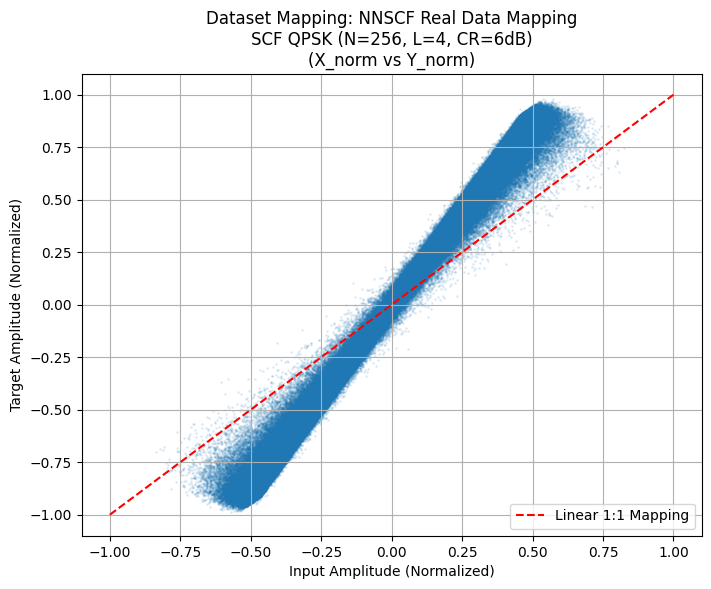

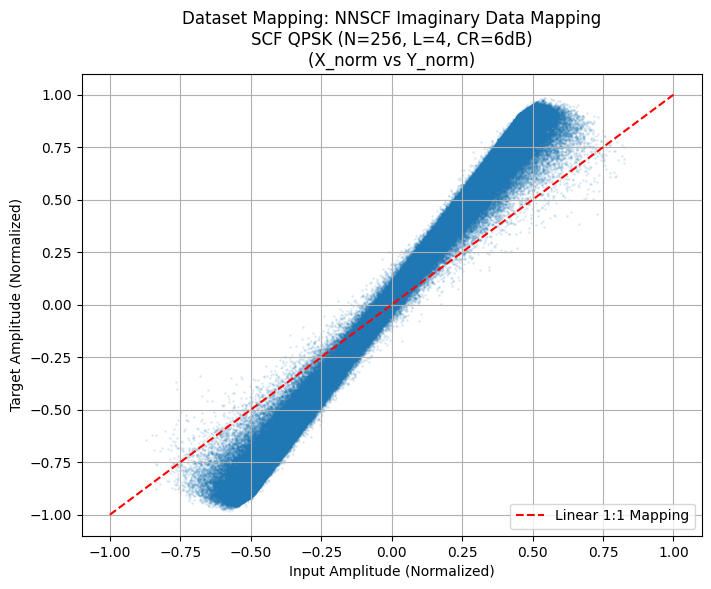

In [8]:
plot_dataset_mapping(os.path.join(pt_dir, f"{mod}_scf_part_{0:03d}_real.pt"), "NNSCF Real " + title)
plot_dataset_mapping(os.path.join(pt_dir, f"{mod}_scf_part_{0:03d}_imag.pt"), "NNSCF Imaginary " + title)